In [1]:
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
from scipy.stats import qmc

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DEV_T = torch.device("cpu")
torch.set_default_dtype(torch.float64)

DELTA2 = 0.0025
X_MIN, X_MAX, T_MIN, T_MAX = -1.0, 1.0, 0.0, 1.0
L = X_MAX - X_MIN

# --- quantum config ---
N_QUBITS  = 4
ENC_WIDTH = 32
ENC_DEPTH = 3
N_VAR_LAYERS = 2
N_REUPLOAD = 1
DEC_WIDTH = 32
DEC_DEPTH = 2       
ENCODING = "angle"

# --- training ---
N_F, N_B, N_0 = 18000, 914, 512
EPOCHS, LR, BATCH_F = 20000, 1e-3, 512

print(f"torch device: {DEV_T}")

torch device: cpu


In [2]:
### Quantum Layer 
def make_qnode(n_qubits, n_var_layers, n_reupload, backend="default.qubit"):
    dev = qml.device(backend, wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(angles, weights):
        for r in range(n_reupload):
            for q in range(n_qubits):
                qml.RY(angles[..., q], wires=q)
            for l in range(n_var_layers):
                for q in range(n_qubits):
                    qml.Rot(weights[r, l, q, 0],
                            weights[r, l, q, 1],
                            weights[r, l, q, 2], wires=q)
                
                if n_qubits >1:
                    for q in range(n_qubits):
                        qml.CZ(wires= [q, (q+1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
    
    return circuit, (n_reupload, n_var_layers, n_qubits, 3)


def make_amplitude_qnode(n_qubits, n_var_layers, backend="default.qubit"):
    """Amplitude encoding branch: 2^n latent features -> normalized state."""
    dev = qml.device(backend, wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(vec, weights):
        qml.AmplitudeEmbedding(vec, wires=range(n_qubits),
                               normalize=True, pad_with=0.0)
        for l in range(n_var_layers):
            for q in range(n_qubits):
                qml.Rot(weights[l, q, 0], weights[l, q, 1],
                        weights[l, q, 2], wires=q)
            if n_qubits > 1:
                for q in range(n_qubits):
                    qml.CZ(wires=[q, (q + 1) % n_qubits])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]

    return circuit, (n_var_layers, n_qubits, 3)          

In [3]:
class Sine(nn.Module):
    def __init__(self, w0=1.0):
        super().__init__(); self.w0 = w0
    def forward(self, x): return torch.sin(self.w0 * x)


def mlp(din, dout, width, depth, act="tanh"):
    A = {"tanh": nn.Tanh, "sine": Sine, "gelu": nn.GELU}[act]
    if depth == 0:
        return nn.Sequential(nn.Linear(din, dout))
    layers, d = [], din
    for _ in range(depth):
        layers += [nn.Linear(d, width), A()]; d = width
    layers += [nn.Linear(d, dout)]
    return nn.Sequential(*layers)


class SandwichQAPINN(nn.Module):
    """INPUT -> classical hidden -> encoding -> QNODE -> classical -> OUTPUT."""

    def __init__(self, n_qubits=N_QUBITS, enc_width=ENC_WIDTH, enc_depth=ENC_DEPTH,
                 n_var_layers=N_VAR_LAYERS, n_reupload=N_REUPLOAD,
                 dec_width=DEC_WIDTH, dec_depth=DEC_DEPTH,
                 encoding=ENCODING, enc_act="sine"):
        super().__init__()
        self.n_qubits, self.encoding = n_qubits, encoding
        self.n_reupload, self.n_var_layers = n_reupload, n_var_layers

        if encoding == "angle":
            latent = n_qubits
            self.qnode, wshape = make_qnode(n_qubits, n_var_layers, n_reupload)
        elif encoding == "amplitude":
            latent = 2 ** n_qubits
            self.qnode, wshape = make_amplitude_qnode(n_qubits, n_var_layers)
        else:
            raise ValueError(encoding)

        self.encoder = mlp(2, latent, enc_width, enc_depth, act=enc_act)
        self.q_weights = nn.Parameter(0.1 * torch.randn(*wshape))
        self.decoder = mlp(n_qubits, 1, dec_width, dec_depth, act="tanh")

        # learnable input scale: lets the model choose its own frequency band
        self.enc_scale = nn.Parameter(torch.tensor(np.pi))

    def forward(self, x, t):
        xs = 2.0 * (x - X_MIN) / L - 1.0
        ts = 2.0 * (t - T_MIN) / (T_MAX - T_MIN) - 1.0
        z = self.encoder(torch.cat([xs, ts], dim=1))

        if self.encoding == "angle":
            z = self.enc_scale * torch.tanh(z)   # bounded, then scaled
            
        w = self.q_weights
        out = self.qnode(z, w)

        if not torch.is_tensor(out):
            out = torch.stack(out, dim=-1)
        
        return self.decoder(out)

    def param_split(self):
        q = self.q_weights.numel()
        e = sum(p.numel() for p in self.encoder.parameters())
        dd = sum(p.numel() for p in self.decoder.parameters())
        return dict(encoder=e, quantum=q, decoder=dd, total=q + e + dd + 1)


net = SandwichQAPINN().to(DEV_T)
print(net.param_split())

{'encoder': 2340, 'quantum': 24, 'decoder': 1249, 'total': 3614}


In [4]:
def sample_points():
    eng = qmc.LatinHypercube(d=2, seed=SEED); s = eng.random(N_F)
    xf = X_MIN + s[:, 0:1] * L
    tf = T_MIN + s[:, 1:2] * (T_MAX - T_MIN)
    x0 = np.linspace(X_MIN, X_MAX, N_0).reshape(-1, 1)
    t0 = np.zeros_like(x0); u0 = np.cos(np.pi * x0)
    n_pair = N_B // 2
    tb = np.random.rand(n_pair, 1) * (T_MAX - T_MIN) + T_MIN
    T = lambda a, rg=False: torch.tensor(a, device=DEV_T, requires_grad=rg)
    return dict(xf=T(xf, True), tf=T(tf, True), x0=T(x0), t0=T(t0), u0=T(u0),
                xbL=T(np.full_like(tb, X_MIN), True),
                xbR=T(np.full_like(tb, X_MAX), True), tb=T(tb, True))

P = sample_points()

def d(y, x, order=1):
    for _ in range(order):
        y = torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]
    return y

def pde_residual(model, x, t):
    u = model(x, t)
    return d(u, t) + u * d(u, x) - DELTA2 * d(d(u, x), x, 2)

def periodic_loss(model, xL, xR, tb):
    uL, uR = model(xL, tb), model(xR, tb)
    uLx, uRx = d(uL, xL), d(uR, xR)
    mse = nn.functional.mse_loss
    return (mse(uL, uR) + mse(uLx, uRx)
            + mse(d(uLx, xL), d(uRx, xR)))

In [5]:
W_F, W_0, W_B = 1.0, 100.0, 100.0
opt = torch.optim.Adam(net.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-5)
mse = nn.functional.mse_loss
hist = {"total": [], "f": [], "ic": [], "bc": [], "scale": []}
n_f = P["xf"].shape[0]

for ep in range(5000 + 1):
    idx = torch.randperm(n_f)[:BATCH_F]
    xb = P["xf"][idx].detach().requires_grad_(True)
    tb_ = P["tf"][idx].detach().requires_grad_(True)

    opt.zero_grad()
    r = pde_residual(net, xb, tb_)
    Lf = mse(r, torch.zeros_like(r))
    L0 = mse(net(P["x0"], P["t0"]), P["u0"])
    Lb = periodic_loss(net, P["xbL"], P["xbR"], P["tb"])
    loss = W_F * Lf + W_0 * L0 + W_B * Lb
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
    opt.step(); sched.step()

    for k, v in zip(["total", "f", "ic", "bc"], [loss, Lf, L0, Lb]):
        hist[k].append(v.item())
    hist["scale"].append(net.enc_scale.item())

    if ep % 250 == 0:
        print(f"{ep:5d} total {loss.item():.3e} | f {Lf.item():.3e} "
              f"ic {L0.item():.3e} bc {Lb.item():.3e} | scale {net.enc_scale.item():.2f}")

    0 total 5.290e+01 | f 3.692e-05 ic 5.290e-01 bc 2.461e-05 | scale 3.14
  250 total 3.011e+00 | f 6.618e-01 ic 1.221e-02 bc 1.128e-02 | scale 3.21
  500 total 1.444e+00 | f 7.734e-01 ic 4.214e-03 bc 2.496e-03 | scale 3.23
  750 total 1.358e+00 | f 7.027e-01 ic 2.518e-03 bc 4.034e-03 | scale 3.23
 1000 total 1.455e+00 | f 7.615e-01 ic 2.030e-03 bc 4.903e-03 | scale 3.23
 1250 total 1.043e+00 | f 6.695e-01 ic 1.564e-03 bc 2.169e-03 | scale 3.23
 1500 total 1.316e+00 | f 6.751e-01 ic 1.504e-03 bc 4.901e-03 | scale 3.23
 1750 total 1.054e+00 | f 6.140e-01 ic 1.363e-03 bc 3.040e-03 | scale 3.23
 2000 total 1.240e+00 | f 6.527e-01 ic 1.031e-03 bc 4.841e-03 | scale 3.23
 2250 total 9.723e-01 | f 5.188e-01 ic 1.078e-03 bc 3.457e-03 | scale 3.23
 2500 total 1.115e+00 | f 6.143e-01 ic 9.972e-04 bc 4.014e-03 | scale 3.23
 2750 total 1.049e+00 | f 5.733e-01 ic 8.283e-04 bc 3.928e-03 | scale 3.23
 3000 total 9.141e-01 | f 5.401e-01 ic 8.041e-04 bc 2.935e-03 | scale 3.22
 3250 total 8.720e-01 | f

In [6]:
import json, time
tag = f"sandwich_kdv_q{N_QUBITS}_R{N_REUPLOAD}_{ENCODING}"
meta = dict(n_qubits=N_QUBITS, n_var_layers=N_VAR_LAYERS, n_reupload=N_REUPLOAD,
            enc_width=ENC_WIDTH, enc_depth=ENC_DEPTH,
            dec_width=DEC_WIDTH, dec_depth=DEC_DEPTH, encoding=ENCODING,
            delta2=DELTA2, seed=SEED, epochs=EPOCHS, batch_f=BATCH_F,
            weights=[W_F, W_0, W_B], params=net.param_split(),
            final_enc_scale=net.enc_scale.item(), timestamp=time.time())
torch.save({"state_dict": net.state_dict(), **meta}, f"{tag}.pt")
np.save(f"{tag}_loss.npy", np.array([hist[k] for k in ["total","f","ic","bc"]]))
json.dump(meta, open(f"{tag}_meta.json", "w"), indent=2, default=str)

In [8]:
# ============================================================
#  Reference solution: Fourier pseudospectral + ETDRK4
#  Equation:  u_t + u u_x = DELTA2 * u_xxx   (matches pde_residual)
#  Domain:    x in [-1, 1] periodic,  u(x,0) = cos(pi x)
# ============================================================
import numpy as np
from scipy.interpolate import RegularGridInterpolator


def kdv_spectral(N=512, T=1.0, nt_out=201, delta2=DELTA2, dt=2e-5):
    """
    Fourier space:  u_hat_t = L*u_hat + N(u_hat)
        linear      +delta2 * u_xxx  ->  L = delta2*(i k)^3 = -1j*delta2*k**3
        nonlinear   -u u_x           ->  -0.5j*k * FFT(u^2)
    Time integration: ETDRK4 (Kassam & Trefethen 2005).
    """
    Lx = X_MAX - X_MIN
    x = X_MIN + Lx * np.arange(N) / N              # periodic grid, endpoint excluded
    k = 2.0 * np.pi * np.fft.fftfreq(N, d=Lx / N)  # wavenumbers for [X_MIN, X_MAX]

    u = np.cos(np.pi * x)
    v = np.fft.fft(u)

    Lop = -1j * delta2 * k**3                      # (ik)^3 = -i k^3

    nsteps = int(round(T / dt))
    h = T / nsteps

    # --- ETDRK4 coefficients via complex contour integral ---
    E, E2 = np.exp(h * Lop), np.exp(h * Lop / 2.0)
    M = 32
    r = np.exp(1j * np.pi * (np.arange(1, M + 1) - 0.5) / M)
    LR = h * Lop[:, None] + r[None, :]

    Q  = h * np.real(np.mean((np.exp(LR / 2) - 1) / LR, axis=1))
    f1 = h * np.real(np.mean((-4 - LR + np.exp(LR) * (4 - 3*LR + LR**2)) / LR**3, axis=1))
    f2 = h * np.real(np.mean(( 2 + LR + np.exp(LR) * (-2 + LR)) / LR**3, axis=1))
    f3 = h * np.real(np.mean((-4 - 3*LR - LR**2 + np.exp(LR) * (4 - LR)) / LR**3, axis=1))

    # 2/3 dealiasing mask -- essential, the quadratic term aliases badly
    mask = np.abs(k) < (2.0 / 3.0) * np.max(np.abs(k))
    g = -0.5j * k
    def NL(v):
        u_r = np.real(np.fft.ifft(v))
        return mask * g * np.fft.fft(u_r ** 2)

    out_every = max(1, nsteps // (nt_out - 1))
    U, tsave = [np.real(np.fft.ifft(v)).copy()], [0.0]

    for n in range(1, nsteps + 1):
        Nv = NL(v)
        a = E2 * v + Q * Nv;               Na = NL(a)
        b = E2 * v + Q * Na;               Nb = NL(b)
        c = E2 * a + Q * (2 * Nb - Nv);    Nc = NL(c)
        v = E * v + Nv * f1 + 2 * (Na + Nb) * f2 + Nc * f3

        if n % out_every == 0 or n == nsteps:
            U.append(np.real(np.fft.ifft(v)).copy())
            tsave.append(n * h)

    return x, np.array(tsave), np.array(U).T        # (N, n_t)


x_ref, t_ref, U_ref = kdv_spectral()
print("reference grid:", U_ref.shape, " t range:", t_ref[0], "->", t_ref[-1])

reference grid: (512, 201)  t range: 0.0 -> 1.0


mass      drift: 1.943e-16
momentum  drift: 1.665e-03
max |u|: 2.3078   (should stay ~O(1), no blowup)


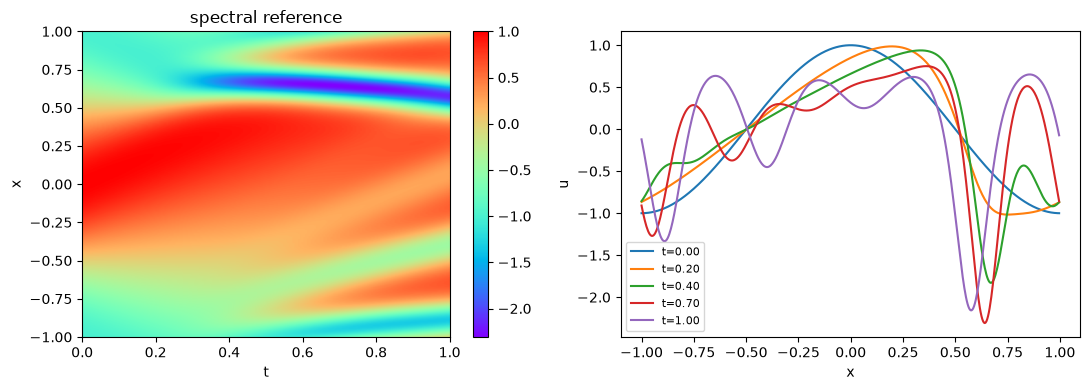

In [9]:
# KdV conserves mass and momentum exactly; the solver should too.
dx = (X_MAX - X_MIN) / U_ref.shape[0]
I1 = U_ref.sum(axis=0) * dx           # int u dx   -> 0 for cos(pi x)
I2 = (U_ref**2).sum(axis=0) * dx      # int u^2 dx -> 1.0

print(f"mass      drift: {np.abs(I1 - I1[0]).max():.3e}")
print(f"momentum  drift: {np.abs(I2 - I2[0]).max()/I2[0]:.3e}")
print(f"max |u|: {np.abs(U_ref).max():.4f}   (should stay ~O(1), no blowup)")

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(U_ref, extent=[t_ref[0], t_ref[-1], X_MIN, X_MAX],
           origin="lower", aspect="auto", cmap="rainbow")
plt.colorbar(); plt.xlabel("t"); plt.ylabel("x"); plt.title("spectral reference")
plt.subplot(1,2,2)
for tv in [0.0, 0.2, 0.4, 0.7, 1.0]:
    j = np.argmin(abs(t_ref - tv))
    plt.plot(x_ref, U_ref[:, j], label=f"t={t_ref[j]:.2f}")
plt.legend(fontsize=8); plt.xlabel("x"); plt.ylabel("u")
plt.tight_layout(); plt.show()

U_exact: (512, 201)  range: -2.3071 1.0
sandwich QA-PINN relative L2: 6.7340e-01


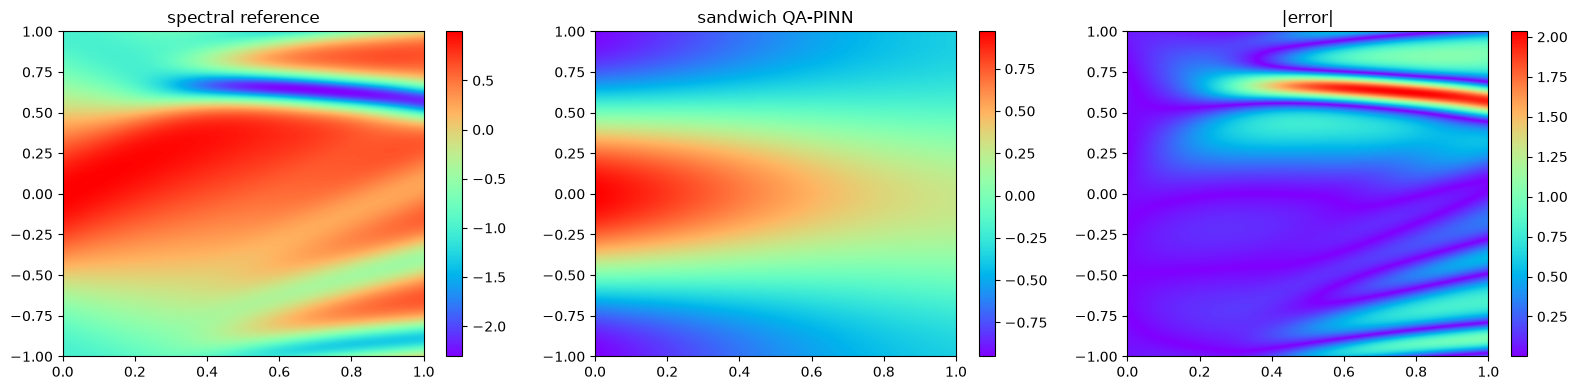

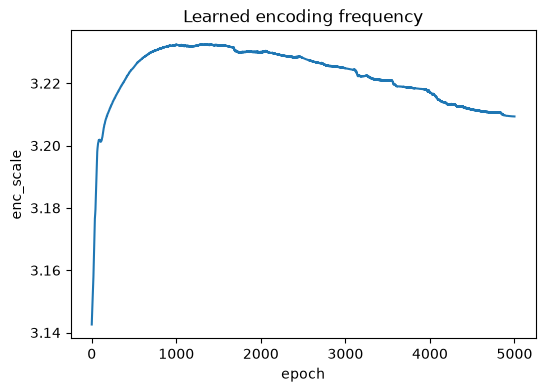

In [10]:
nx, nt = 512, 201
xg, tg = np.linspace(X_MIN, X_MAX, nx), np.linspace(T_MIN, T_MAX, nt)
XX, TT = np.meshgrid(xg, tg, indexing="ij")
_interp = RegularGridInterpolator(
    (x_ref, t_ref), U_ref, method="linear", bounds_error=False, fill_value=None
)
_pts = np.stack([
    np.clip(XX.ravel(), x_ref[0], x_ref[-1]),   # x_ref excludes +1 (periodic grid)
    np.clip(TT.ravel(), t_ref[0], t_ref[-1]),
], axis=-1)
U_exact = _interp(_pts).reshape(nx, nt)

print("U_exact:", U_exact.shape, " range:", U_exact.min().round(4), U_exact.max().round(4))

def predict(model, B=2048):
    xa = torch.tensor(XX.reshape(-1, 1)); ta = torch.tensor(TT.reshape(-1, 1))
    out = []
    with torch.no_grad():
        for i in range(0, xa.shape[0], B):
            out.append(model(xa[i:i+B], ta[i:i+B]).cpu().numpy())
    return np.concatenate(out).reshape(nx, nt)

U_s = predict(net)
rel = np.linalg.norm(U_s - U_exact) / np.linalg.norm(U_exact)
print(f"sandwich QA-PINN relative L2: {rel:.4e}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, dat, ttl in zip(ax, [U_exact, U_s, np.abs(U_s - U_exact)],
                       ["spectral reference", "sandwich QA-PINN", "|error|"]):
    im = a.imshow(dat, extent=[T_MIN, T_MAX, X_MIN, X_MAX], origin="lower",
                  aspect="auto", cmap="rainbow")
    a.set_title(ttl); plt.colorbar(im, ax=a)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4)); plt.plot(hist["scale"])
plt.xlabel("epoch"); plt.ylabel("enc_scale"); plt.title("Learned encoding frequency"); plt.show()

In [11]:
def latent_stats(model, n=2000):
    x = torch.rand(n,1)*L + X_MIN; t = torch.rand(n,1)*(T_MAX-T_MIN) + T_MIN
    with torch.no_grad():
        z = model.encoder(torch.cat([2*(x-X_MIN)/L-1, 2*(t-T_MIN)/(T_MAX-T_MIN)-1], 1))
        ang = model.enc_scale * torch.tanh(z)
        q = model.qnode(ang, model.q_weights)
        q = torch.stack(q, -1) if not torch.is_tensor(q) else q
    return ang.numpy(), q.numpy()

ang, qout = latent_stats(net)
print("angle range per wire:", ang.min(0), ang.max(0))
print("qubit <Z> std per wire:", qout.std(0))
print("qubit <Z> corr matrix:\n", np.corrcoef(qout.T).round(3))

angle range per wire: [-2.30552542 -1.70938757 -2.44358964 -1.97330806] [ 0.58516418  2.23886178  0.67299513 -1.2634299 ]
qubit <Z> std per wire: [0.55283938 0.38303401 0.6271379  0.16089771]
qubit <Z> corr matrix:
 [[ 1.     0.058 -0.824  0.73 ]
 [ 0.058  1.     0.002  0.392]
 [-0.824  0.002  1.    -0.424]
 [ 0.73   0.392 -0.424  1.   ]]


In [12]:
class ClassicalTwin(nn.Module):
    """Same encoder/decoder, circuit replaced by a fixed random projection."""
    def __init__(self, ref):
        super().__init__()
        self.encoder = mlp(2, ref.n_qubits, ENC_WIDTH, ENC_DEPTH, act="sine")
        self.decoder = mlp(ref.n_qubits, 1, DEC_WIDTH, DEC_DEPTH, act="tanh")
        self.register_buffer("Wr", torch.randn(ref.n_qubits, ref.n_qubits) / np.sqrt(ref.n_qubits))
    def forward(self, x, t):
        xs = 2*(x-X_MIN)/L - 1; ts = 2*(t-T_MIN)/(T_MAX-T_MIN) - 1
        z = torch.tanh(self.encoder(torch.cat([xs, ts], 1)))
        return self.decoder(torch.tanh(z @ self.Wr))

def quick_train(model, epochs=1500):
    o = torch.optim.Adam(model.parameters(), lr=LR)
    for _ in range(epochs):
        i = torch.randperm(n_f)[:BATCH_F]
        xb = P["xf"][i].detach().requires_grad_(True)
        tb_ = P["tf"][i].detach().requires_grad_(True)
        o.zero_grad()
        r = pde_residual(model, xb, tb_)
        l = (mse(r, torch.zeros_like(r)) + 100*mse(model(P["x0"],P["t0"]), P["u0"])
             + 100*periodic_loss(model, P["xbL"], P["xbR"], P["tb"]))
        l.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); o.step()
    return model, l.item()

arms = {}
torch.manual_seed(SEED); arms["sandwich"] = quick_train(SandwichQAPINN())
torch.manual_seed(SEED); arms["classical_twin"] = quick_train(ClassicalTwin(SandwichQAPINN()))
torch.manual_seed(SEED); arms["frozen_circuit"] = quick_train(
    (lambda m: [m.q_weights.requires_grad_(False), m][1])(SandwichQAPINN()))

for k, (m, l) in arms.items():
    U = predict(m)
    print(f"{k:16s} loss {l:.3e}  relL2 "
          f"{np.linalg.norm(U-U_exact)/np.linalg.norm(U_exact):.4e}")

sandwich         loss 1.083e+00  relL2 6.9384e-01
classical_twin   loss 2.202e+00  relL2 7.1881e-01
frozen_circuit   loss 1.251e+00  relL2 6.9164e-01


In [13]:
sweep = {}
for R in [1, 2, 4, 6]:
    torch.manual_seed(SEED)
    m, l = quick_train(SandwichQAPINN(n_reupload=R))
    U = predict(m)
    sweep[R] = dict(loss=l, rel=np.linalg.norm(U-U_exact)/np.linalg.norm(U_exact),
                    scale=m.enc_scale.item(), params=m.param_split()["total"])
    print(f"R={R}: loss {l:.3e} relL2 {sweep[R]['rel']:.4e} "
          f"scale {sweep[R]['scale']:.2f} params {sweep[R]['params']}")

R=1: loss 1.083e+00 relL2 6.9384e-01 scale 3.23 params 3614
R=2: loss 1.238e+00 relL2 7.5314e-01 scale 3.18 params 3638
R=4: loss 1.011e+00 relL2 6.9719e-01 scale 3.15 params 3686
R=6: loss 4.457e+00 relL2 7.1882e-01 scale 3.11 params 3734
